## Cell 1: settings and find class folders

In [1]:
import random, shutil
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import albumentations as A
from sklearn.model_selection import train_test_split

# ---------- settings ----------
INPUT_ROOT = Path("/kaggle/input/datasets/bhanukachamindu/aloe-vera-disease-dataset")
OUT_DIR = Path("/kaggle/working/aloe_dataset")
IMG_SIZE = 224                       # every image is resized to IMG_SIZE x IMG_SIZE
TARGET_MIN, TARGET_MAX = 3700, 3800  # train images per class
MAX_AUG_FACTOR = 12                  # a class never gets more than 12x its real train images
VAL_FRAC, TEST_FRAC = 0.15, 0.15
SEED = 42
MERGE = {}                           # healthy is already one folder
EXPECTED_CLASSES = 5                 # aloe rust, fungal infection, leaf spot, rot, healthy
RUN_GROUP_SPLIT = False              # True = leak-safe split in Cell 2b (slower)
# ------------------------------

random.seed(SEED)
np.random.seed(SEED)

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SPLIT_NAMES = {"train", "training", "val", "valid", "validation", "test", "testing"}

def is_img(f):
    return f.is_file() and f.suffix.lower() in IMG_EXT

def find_class_root(root):
    """Go down through wrapper folders until we reach the folder that holds the class folders."""
    cur = Path(root)
    while True:
        subdirs = sorted(p for p in cur.iterdir() if p.is_dir())
        if len(subdirs) == 1 and not any(is_img(f) for f in cur.iterdir()):
            cur = subdirs[0]
        else:
            return cur

DATA_DIR = find_class_root(INPUT_ROOT)
top = sorted(p for p in DATA_DIR.iterdir() if p.is_dir())

if top and all(p.name.strip().lower() in SPLIT_NAMES for p in top):
    class_dirs = sorted(c for s in top for c in s.iterdir() if c.is_dir())
    print("Dataset is already split into", [p.name for p in top],
          "-> pooling all images and re-splitting")
else:
    class_dirs = top

print("Using folder:", DATA_DIR, "\n")
for c in class_dirs:
    n = sum(1 for f in c.rglob("*") if is_img(f))
    print(f"  {c.parent.name}/{c.name:28s} {n}")

Using folder: /kaggle/input/datasets/bhanukachamindu/aloe-vera-disease-dataset/Aloe_Vera_Dataset_Disease 

  Aloe_Vera_Dataset_Disease/Aloe_Rust                    2068
  Aloe_Vera_Dataset_Disease/Fungal_Infection             3734
  Aloe_Vera_Dataset_Disease/Healthy                      1823
  Aloe_Vera_Dataset_Disease/Leaf_Spot                    3764
  Aloe_Vera_Dataset_Disease/Rot                          64


## Cell 2: collect images and split (random, stratified)

In [2]:
def class_name(folder_name):
    key = folder_name.strip().lower().replace("_", " ")
    return MERGE.get(key, key.replace(" ", "_"))

rows = []
for c in class_dirs:
    for f in c.rglob("*"):
        if is_img(f):
            rows.append({"path": str(f), "source_folder": c.name, "label": class_name(c.name)})

df = pd.DataFrame(rows)
if df["label"].nunique() < 2:
    raise ValueError(f"Only {df['label'].nunique()} class found: {df['label'].unique()}. "
                     "INPUT_ROOT is pointing at the wrong folder - check the Cell 1 printout.")

if df["label"].nunique() != EXPECTED_CLASSES:
    print(f"WARNING: expected {EXPECTED_CLASSES} classes but found {df['label'].nunique()}: {sorted(df['label'].unique())}\n")

print("Original counts:")
print(df["label"].value_counts(), "\n")

train_df, temp_df = train_test_split(
    df, test_size=VAL_FRAC + TEST_FRAC, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=temp_df["label"], random_state=SEED)

print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")

Original counts:
label
leaf_spot           3764
fungal_infection    3734
aloe_rust           2068
healthy             1823
rot                   64
Name: count, dtype: int64 

train 8017 | val 1718 | test 1718


## Cell 2b (optional): leak-safe split

Some datasets contain flipped / brighter / re-saved copies of the same leaf. With a random split, copies of one leaf can land in both train and test, and your test scores then look better than they really are.

Set `RUN_GROUP_SPLIT = True` in Cell 1 to use this. It fingerprints every image, groups copies of the same leaf, and splits by group. It takes 2-4 minutes and **replaces** `train_df`, `val_df`, `test_df` from Cell 2. With the default `False` it does nothing.

It catches flipped, brightness-changed, resized and re-saved copies. It can miss copies that were rotated or cropped a lot.

In [3]:
if not RUN_GROUP_SPLIT:
    print("Skipped (RUN_GROUP_SPLIT = False). Using the random split from Cell 2.")
else:
    from sklearn.model_selection import StratifiedGroupKFold
    from scipy.sparse import coo_matrix
    from scipy.sparse.csgraph import connected_components
    import matplotlib.pyplot as plt

    MAX_GROUP = 60      # a set of copies of one leaf is never expected to be bigger than this
    FORCE_T = None      # leave as None; the code picks the similarity threshold itself

    # ---- fingerprint: 256 bits, flip-proof ----
    def dhash256(gray):
        small = cv2.resize(gray, (17, 16), interpolation=cv2.INTER_AREA)
        bits = (small[:, 1:] > small[:, :-1]).flatten()
        return np.packbits(bits).view(">u8").astype(np.uint64)

    def canonical_hash(path):
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        cands = [dhash256(v) for v in (img, img[:, ::-1], img[::-1, :], img[::-1, ::-1])]
        return min(cands, key=lambda a: tuple(a.tolist()))

    print("Fingerprinting images (1-3 minutes)...")
    hashes = [canonical_hash(p) for p in df["path"]]
    df = df[[x is not None for x in hashes]].reset_index(drop=True)
    H = np.stack([x for x in hashes if x is not None])           # N x 4 (uint64)
    N = len(H)

    # ---- find all pairs of similar images (distance in bits, out of 256) ----
    POP = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)
    MAXT = 30
    pi, pj, pd_ = [], [], []
    for s in range(0, N, 150):
        x = H[s:s + 150, None, :] ^ H[None, :, :]
        d = POP[x.view(np.uint8)].sum(axis=2, dtype=np.int32)
        rr, cc = np.nonzero(d <= MAXT)
        ok = (s + rr) < cc
        pi.append(s + rr[ok]); pj.append(cc[ok]); pd_.append(d[rr[ok], cc[ok]])
    P_i, P_j, P_d = np.concatenate(pi), np.concatenate(pj), np.concatenate(pd_)

    def groups_at(t):
        m = P_d <= t
        g = coo_matrix((np.ones(m.sum()), (P_i[m], P_j[m])), shape=(N, N))
        return connected_components(g, directed=False)[1]

    print("\nSweep: how similar must two images be to count as copies?")
    print(" bits  largest_group  images_in_groups_of_2+")
    best_t = 0
    for t in [0, 2, 4, 6, 8, 12, 16, 20, 24, 30]:
        lab = groups_at(t)
        sz = np.bincount(lab)
        print(f" {t:4d}  {sz.max():13d}  {int(sz[sz > 1].sum()):22d}")
        if sz.max() <= MAX_GROUP:
            best_t = t
    T = FORCE_T if FORCE_T is not None else best_t
    print(f"\nUsing threshold: {T} bits")

    df["group"] = groups_at(T)
    sizes = df.groupby("group").size()

    print("\nImages per class vs. UNIQUE leaves (groups of copies count once):")
    print(pd.DataFrame({"images": df.groupby("label").size(),
                        "unique_leaves": df.groupby("label")["group"].nunique()}))
    print(f"\nlargest group: {sizes.max()} images | groups with 2+ images: {(sizes > 1).sum()}")

    # ---- split by group ----
    sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)   # 7 folds -> about 14% each
    folds = [f[1] for f in sgkf.split(df, df["label"], groups=df["group"])]
    test_df = df.iloc[folds[0]]
    val_df = df.iloc[folds[1]]
    train_df = df.iloc[np.concatenate(folds[2:])]

    leak = set(train_df["group"]) & (set(val_df["group"]) | set(test_df["group"]))
    leak |= set(val_df["group"]) & set(test_df["group"])
    print(f"\ntrain {len(train_df)} | val {len(val_df)} | test {len(test_df)} | leaves shared between splits: {len(leak)}")
    print(pd.DataFrame({"train": train_df["label"].value_counts(),
                        "val": val_df["label"].value_counts(),
                        "test": test_df["label"].value_counts()}))

    # ---- look at a few groups: each row should be the same leaf ----
    multi = sizes[sizes > 1].index.tolist()
    show = random.sample(multi, min(5, len(multi)))
    fig, axes = plt.subplots(max(len(show), 1), 4, figsize=(10, 2.3 * max(len(show), 1)), squeeze=False)
    for r, g in enumerate(show):
        files = df[df["group"] == g]["path"].tolist()[:4]
        for k in range(4):
            axes[r, k].axis("off")
            if k < len(files):
                axes[r, k].imshow(cv2.cvtColor(cv2.imread(files[k]), cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    plt.show()

Skipped (RUN_GROUP_SPLIT = False). Using the random split from Cell 2.


## Cell 3: save val and test (real images only, no augmentation)

In [4]:
shutil.rmtree(OUT_DIR, ignore_errors=True)   # safe to re-run

def load_resized(path):
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

def save_split(split_df, split_name):
    for idx, r in split_df.iterrows():
        img = load_resized(r["path"])
        if img is None:
            print("could not read:", r["path"])
            continue
        dst = OUT_DIR / split_name / r["label"]
        dst.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(dst / f"{Path(r['path']).stem}_{idx}.jpg"), img)

save_split(val_df, "val")
save_split(test_df, "test")
print("val and test saved")

val and test saved


## Cell 4: balance the train set

- class has **more** than the target: random sample, no augmentation
- class has **fewer**: keep all real images, add augmented copies, but never more than `MAX_AUG_FACTOR` (12x) the real count. That is why **Rot** (very few real images) ends up much smaller than the others. Class weights (Cell 7) make up for it.

Augmentations are mild (flips, small rotation, small zoom, small brightness change). Colour is not changed, because disease colour matters.

In [5]:
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, p=0.7),
    A.Affine(scale=(0.85, 1.15), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
])

for label, group in train_df.groupby("label"):
    paths = group["path"].tolist()
    target = random.randint(TARGET_MIN, TARGET_MAX)
    target = min(target, len(paths) * MAX_AUG_FACTOR)   # protects tiny classes like Rot
    dst = OUT_DIR / "train" / label
    dst.mkdir(parents=True, exist_ok=True)

    if len(paths) >= target:
        paths = random.sample(paths, target)

    n_real = len(paths)
    n_aug = max(0, target - n_real)
    keep = []
    for i, p in enumerate(paths):
        img = load_resized(p)
        if img is None:
            continue
        cv2.imwrite(str(dst / f"orig_{i}.jpg"), img)
        if n_aug > 0:
            keep.append(img)

    for j in range(n_aug):
        img = random.choice(keep)
        cv2.imwrite(str(dst / f"aug_{j}.jpg"), augment(image=img)["image"])

    msg = f"{label:18s} real: {n_real:5d}  augmented: {n_aug:5d}  total: {n_real + n_aug}"
    if n_real < 500:
        msg += "   <-- few real images, watch for overfitting"
    print(msg)

aloe_rust          real:  1447  augmented:  2334  total: 3781
fungal_infection   real:  2614  augmented:  1145  total: 3759
healthy            real:  1276  augmented:  2426  total: 3702
leaf_spot          real:  2635  augmented:  1111  total: 3746
rot                real:    45  augmented:   495  total: 540   <-- few real images, watch for overfitting


## Cell 5: check the result

In [6]:
for split in ["train", "val", "test"]:
    counts = {c.name: len(list(c.glob("*.jpg"))) for c in sorted((OUT_DIR / split).iterdir())}
    print(split, counts)

manifest = pd.concat([train_df.assign(split="train"),
                      val_df.assign(split="val"),
                      test_df.assign(split="test")])
manifest.to_csv(OUT_DIR / "split_manifest.csv", index=False)

train {'aloe_rust': 3781, 'fungal_infection': 3759, 'healthy': 3702, 'leaf_spot': 3746, 'rot': 540}
val {'aloe_rust': 310, 'fungal_infection': 560, 'healthy': 274, 'leaf_spot': 564, 'rot': 10}
test {'aloe_rust': 311, 'fungal_infection': 560, 'healthy': 273, 'leaf_spot': 565, 'rot': 9}


## Cell 6: sample images (augmented ones should still look like real leaves)

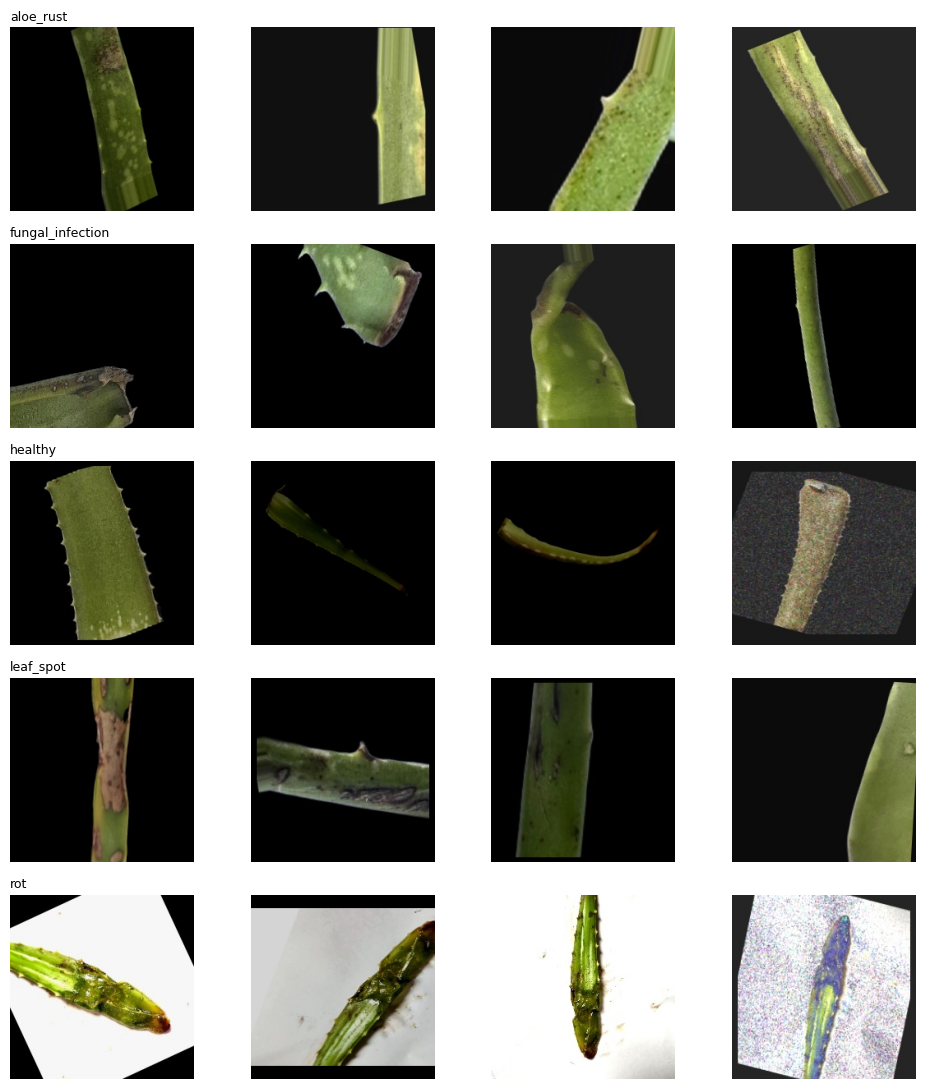

In [7]:
import matplotlib.pyplot as plt

classes = sorted(c.name for c in (OUT_DIR / "train").iterdir())
fig, axes = plt.subplots(len(classes), 4, figsize=(10, 2.2 * len(classes)), squeeze=False)
for r, c in enumerate(classes):
    pool = sorted((OUT_DIR / "train" / c).glob("aug_*.jpg")) or sorted((OUT_DIR / "train" / c).glob("*.jpg"))
    files = random.sample(pool, min(4, len(pool)))
    for k in range(4):
        ax = axes[r, k]
        ax.axis("off")
        if k < len(files):
            ax.imshow(cv2.cvtColor(cv2.imread(str(files[k])), cv2.COLOR_BGR2RGB))
        if k == 0:
            ax.set_title(c, fontsize=9, loc="left")
plt.tight_layout()
plt.show()

## Cell 7: class weights (for training)

In [8]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = []
for c in classes:
    train_labels += [c] * len(list((OUT_DIR / "train" / c).glob("*.jpg")))

weights = compute_class_weight("balanced", classes=np.array(classes), y=np.array(train_labels))
class_weight = {i: float(w) for i, w in enumerate(weights)}   # index order = alphabetical (Keras / ImageFolder order)
print(dict(zip(classes, np.round(weights, 3).tolist())))
# Rot gets the highest weight because it has far fewer train images than the other classes.
# Keras:   model.fit(..., class_weight=class_weight)
# PyTorch: nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))

{'aloe_rust': 0.821, 'fungal_infection': 0.826, 'healthy': 0.839, 'leaf_spot': 0.829, 'rot': 5.751}


## Cell 8: zip (download it, or use *New Dataset* from the Output tab after Save Version)

In [9]:
shutil.make_archive("/kaggle/working/aloe_dataset", "zip", OUT_DIR)
print("zip created: /kaggle/working/aloe_dataset.zip")
# Optional: delete the loose folder to make "Save Version" faster (keep it if you train in this notebook)
# shutil.rmtree(OUT_DIR)

zip created: /kaggle/working/aloe_dataset.zip


In [10]:
import os, random, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# ---------- settings ----------
DATA_ROOT = None        # leave None to find it automatically, or set e.g. Path("/kaggle/working/aloe_dataset")
IMG_SIZE = 224
BATCH = 32
EPOCHS_HEAD = 8         # phase 1: train only the new top layers
EPOCHS_FINE = 12        # phase 2: fine-tune the top of MobileNetV2
SEED = 42
OUT = Path("/kaggle/working")
# ------------------------------

random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

def has_splits(p):
    return all((p / s).is_dir() for s in ("train", "val", "test"))

def find_data_root():
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if not base.exists():
            continue
        for root, dirs, files in os.walk(base):
            if has_splits(Path(root)):
                return Path(root)
    # a zip that was not unpacked?
    for z in list(Path("/kaggle/input").rglob("aloe_dataset*.zip")) + list(Path("/kaggle/working").glob("aloe_dataset*.zip")):
        target = Path("/kaggle/working/aloe_dataset")
        print("Unzipping", z, "->", target)
        with zipfile.ZipFile(z) as f:
            f.extractall(target)
        if has_splits(target):
            return target
    return None

if DATA_ROOT is None:
    DATA_ROOT = find_data_root()
if DATA_ROOT is None or not has_splits(Path(DATA_ROOT)):
    raise FileNotFoundError("Could not find a folder with train/val/test. Run the data-prep notebook first "
                            "or add the aloe_dataset under Add Input, then set DATA_ROOT above.")
DATA_ROOT = Path(DATA_ROOT)
print("Using data:", DATA_ROOT)

TensorFlow 2.20.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Using data: /kaggle/working/aloe_dataset


In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT / "train", image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    label_mode="int", shuffle=True, seed=SEED)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT / "val", image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    label_mode="int", shuffle=False)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT / "test", image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    label_mode="int", shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
test_files = list(test_ds.file_paths)          # keep the order, used to show wrong predictions later
print("classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds_p = test_ds.prefetch(AUTOTUNE)

# class weights from the train folder (as your sir asked)
counts = [len(list((DATA_ROOT / "train" / c).glob("*"))) for c in class_names]
labels_for_w = np.concatenate([[i] * n for i, n in enumerate(counts)])
w = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=labels_for_w)
class_weight = {i: float(x) for i, x in enumerate(w)}
print("train images per class:", dict(zip(class_names, counts)))
print("class weights:", {c: round(class_weight[i], 2) for i, c in enumerate(class_names)})

Found 15528 files belonging to 5 classes.


I0000 00:00:1789927258.840017      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789927258.842932      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1718 files belonging to 5 classes.
Found 1718 files belonging to 5 classes.
classes: ['aloe_rust', 'fungal_infection', 'healthy', 'leaf_spot', 'rot']
train images per class: {'aloe_rust': 3781, 'fungal_infection': 3759, 'healthy': 3702, 'leaf_spot': 3746, 'rot': 540}
class weights: {'aloe_rust': 0.82, 'fungal_infection': 0.83, 'healthy': 0.84, 'leaf_spot': 0.83, 'rot': 5.75}


In [12]:
try:
    base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                             include_top=False, weights="imagenet")
    print("Loaded pretrained ImageNet weights.")
except Exception as e:
    print("!! Could not download pretrained weights (is Internet turned On?):", type(e).__name__)
    print("!! Continuing WITHOUT pretrained weights. Results will be much worse.")
    base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                             include_top=False, weights=None)

base.trainable = False
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.layers.Rescaling(1 / 127.5, offset=-1)(inputs)      # MobileNetV2 expects -1..1
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("parameters:", f"{model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded pretrained ImageNet weights.
parameters: 2,264,389


In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
]

print("=== Phase 1: training the top layers ===")
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
               class_weight=class_weight, callbacks=callbacks)

print("\n=== Phase 2: fine-tuning the top of MobileNetV2 ===")
base.trainable = True
for layer in base.layers[:-40]:                  # keep the early layers frozen
    layer.trainable = False
for layer in base.layers:                        # keep BatchNorm frozen (more stable)
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE,
               class_weight=class_weight, callbacks=callbacks)

=== Phase 1: training the top layers ===
Epoch 1/8


2026-09-20 18:01:16.783346: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:01:16.920873: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789927279.014190      80 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


484/486 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5685 - loss: 0.9994

2026-09-20 18:01:39.551568: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:01:39.688718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


486/486 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5689 - loss: 0.9983

2026-09-20 18:01:55.849687: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-20 18:01:55.987387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


486/486 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.6646 - loss: 0.7360 - val_accuracy: 0.7660 - val_loss: 0.5843 - learning_rate: 0.0010
Epoch 2/8
486/486 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7477 - loss: 0.5182 - val_accuracy: 0.7829 - val_loss: 0.5545 - learning_rate: 0.0010
Epoch 3/8
486/486 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7684 - loss: 0.4776 - val_accuracy: 0.7893 - val_loss: 0.5243 - learning_rate: 0.0010
Epoch 4/8
486/486 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7747 - loss: 0.4624 - val_accuracy: 0.7875 - val_loss: 0.5231 - learning_rate: 0.0010
Epoch 5/8
486/486 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7761 - loss: 0.4600 - val_accuracy: 0.7945 - val_loss: 0.5139 - learning_rate: 0.0010
Epoch 6/8
486/486 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7767 - loss: 0.4587 - val_accuracy: 0.7980 - val_loss: 0.5084 - learning_rate: 0.0010
Epoch 7/8
486/486 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7774 - loss: 0.4541 - val

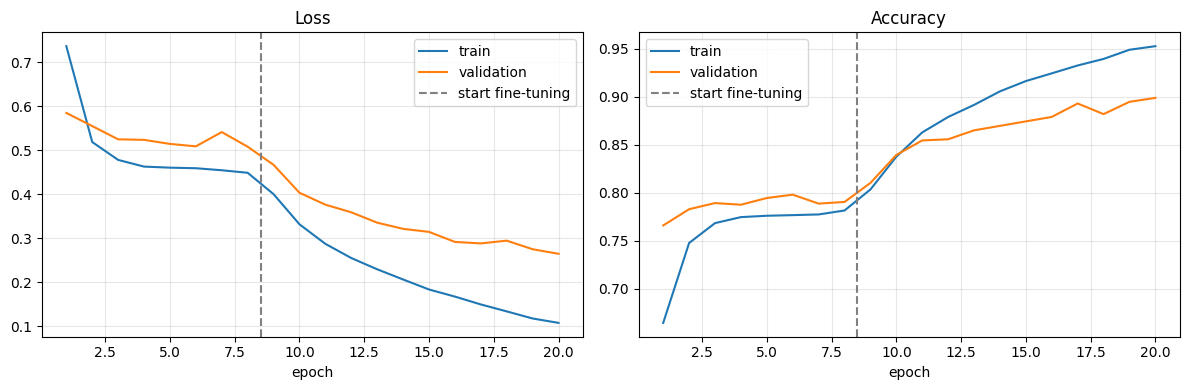

Big gap between train and validation = overfitting.


In [14]:
hist = {k: h1.history[k] + h2.history[k] for k in h1.history}
split_at = len(h1.history["loss"])
epochs = range(1, len(hist["loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, key, title in [(ax[0], "loss", "Loss"), (ax[1], "accuracy", "Accuracy")]:
    a.plot(epochs, hist[key], label="train")
    a.plot(epochs, hist["val_" + key], label="validation")
    a.axvline(split_at + 0.5, color="gray", linestyle="--", label="start fine-tuning")
    a.set_title(title); a.set_xlabel("epoch"); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Big gap between train and validation = overfitting.")

In [15]:
probs = model.predict(test_ds_p, verbose=0)
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = probs.argmax(axis=1)

print("Test accuracy :", round((y_true == y_pred).mean(), 4))
print("Macro F1      :", round(f1_score(y_true, y_pred, average="macro"), 4), "  (the number to trust most)")
print("Weighted F1   :", round(f1_score(y_true, y_pred, average="weighted"), 4))
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))
print("Test images per class:", dict(zip(class_names, np.bincount(y_true, minlength=NUM_CLASSES).tolist())))
print("(a class with only ~10 test images gives an unreliable score: one mistake moves it by ~10%)")

Test accuracy : 0.8842
Macro F1      : 0.9143   (the number to trust most)
Weighted F1   : 0.8846

                  precision    recall  f1-score   support

       aloe_rust      0.787     0.891     0.836       311
fungal_infection      0.919     0.875     0.897       560
         healthy      0.993     0.996     0.995       273
       leaf_spot      0.856     0.834     0.845       565
             rot      1.000     1.000     1.000         9

        accuracy                          0.884      1718
       macro avg      0.911     0.919     0.914      1718
    weighted avg      0.887     0.884     0.885      1718

Test images per class: {'aloe_rust': 311, 'fungal_infection': 560, 'healthy': 273, 'leaf_spot': 565, 'rot': 9}
(a class with only ~10 test images gives an unreliable score: one mistake moves it by ~10%)


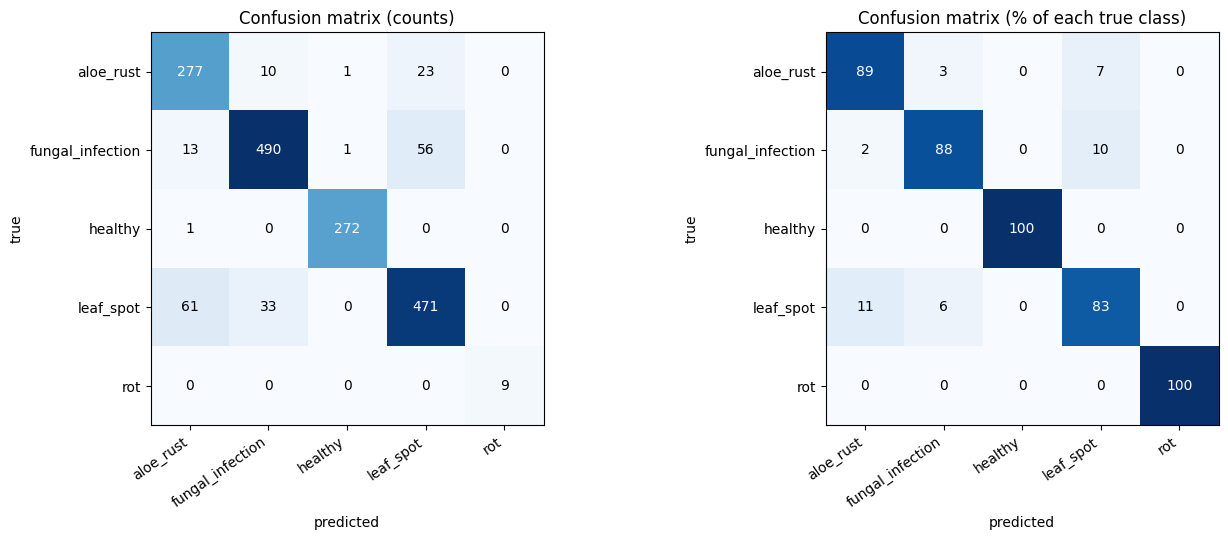

Diseased leaves predicted as healthy: 2   <- the costliest mistake in the app


In [16]:
cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
cm_pct = cm / cm.sum(axis=1, keepdims=True).clip(min=1) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for a, data, title, fmt in [(ax[0], cm, "Confusion matrix (counts)", "d"),
                            (ax[1], cm_pct, "Confusion matrix (% of each true class)", ".0f")]:
    im = a.imshow(data, cmap="Blues")
    a.set_xticks(range(NUM_CLASSES)); a.set_xticklabels(class_names, rotation=35, ha="right")
    a.set_yticks(range(NUM_CLASSES)); a.set_yticklabels(class_names)
    a.set_xlabel("predicted"); a.set_ylabel("true"); a.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            a.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                   color="white" if data[i, j] > data.max() / 2 else "black")
plt.tight_layout(); plt.show()

if "healthy" in class_names:
    hi = class_names.index("healthy")
    missed = int(cm[:, hi].sum() - cm[hi, hi])
    print(f"Diseased leaves predicted as healthy: {missed}   <- the costliest mistake in the app")

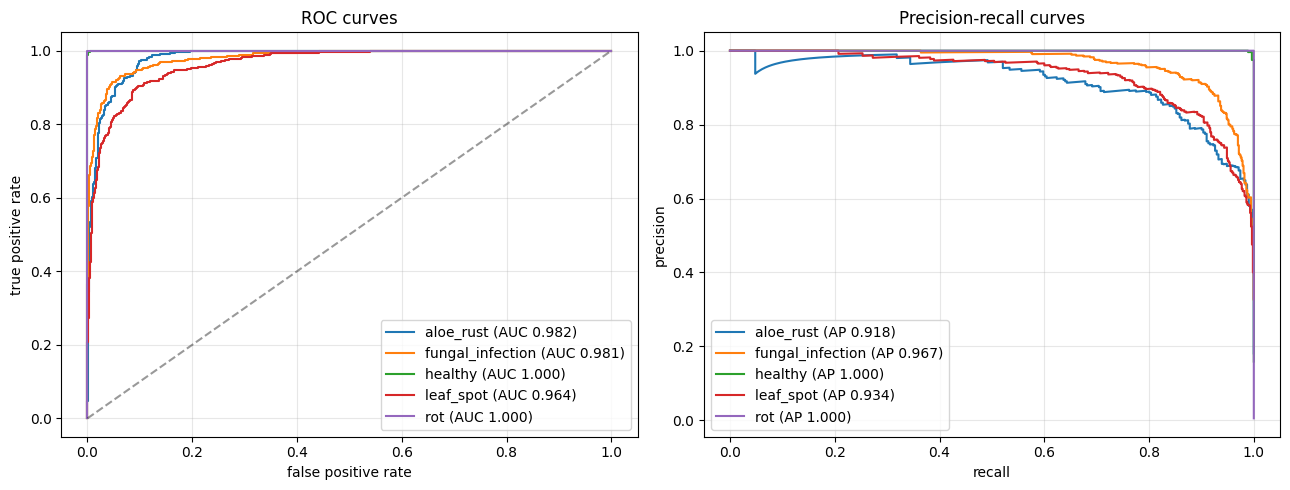

In [17]:
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for i, c in enumerate(class_names):
    if y_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    ax[0].plot(fpr, tpr, label=f"{c} (AUC {auc(fpr, tpr):.3f})")
    p, r, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
    ax[1].plot(r, p, label=f"{c} (AP {average_precision_score(y_bin[:, i], probs[:, i]):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
ax[0].set_title("ROC curves"); ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate")
ax[1].set_title("Precision-recall curves"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
for a in ax:
    a.legend(loc="lower right" if a is ax[0] else "lower left"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

199 wrong out of 1718 test images


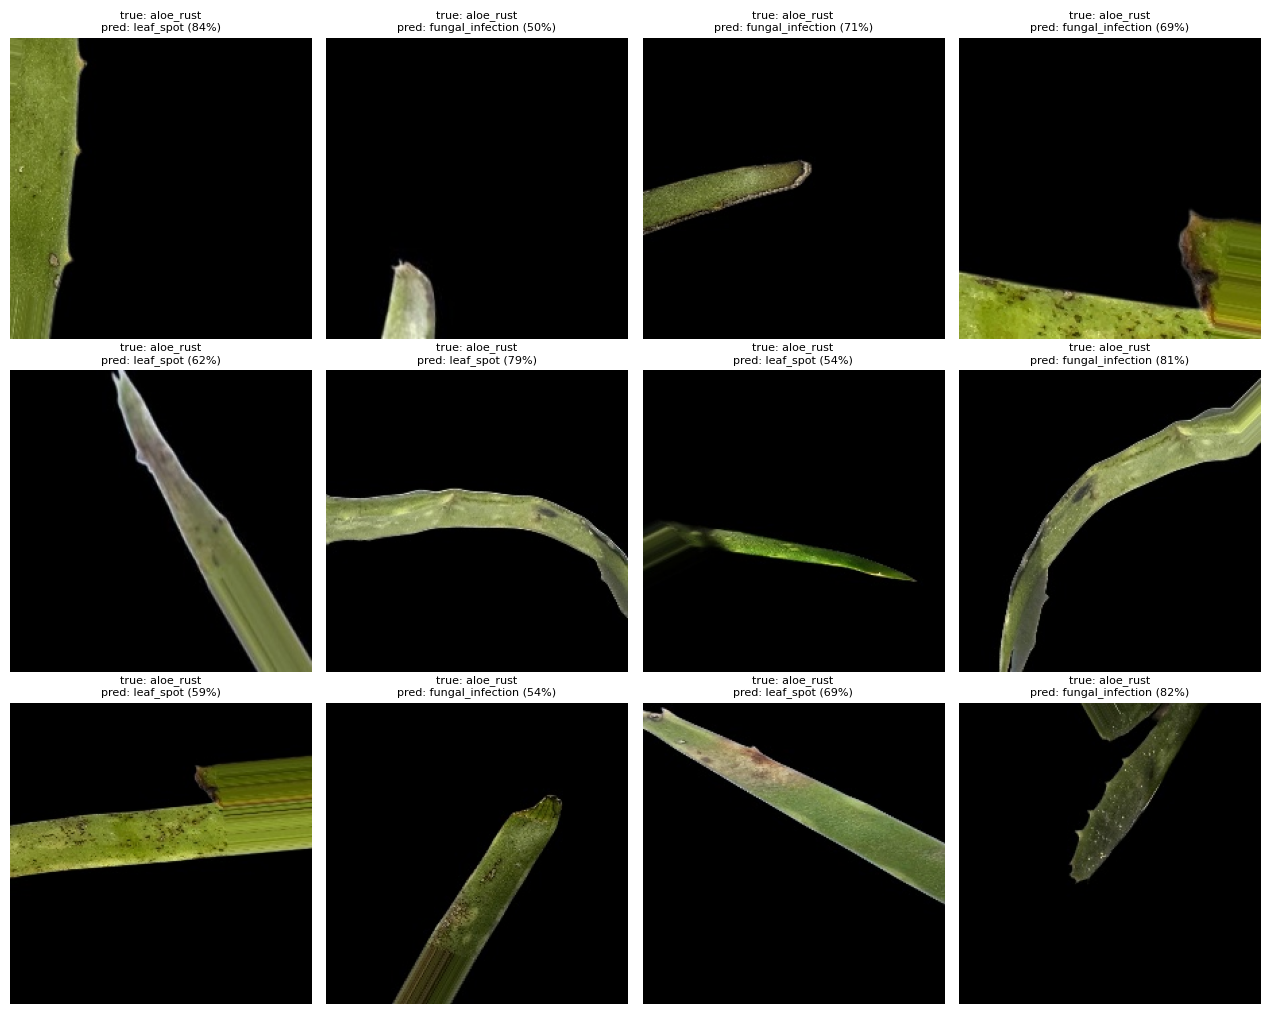

In [18]:
wrong = np.where(y_true != y_pred)[0]
print(f"{len(wrong)} wrong out of {len(y_true)} test images")
show = wrong[:12]
if len(show):
    cols = 4
    rows = int(np.ceil(len(show) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.4 * rows), squeeze=False)
    for a in axes.ravel():
        a.axis("off")
    for a, idx in zip(axes.ravel(), show):
        a.imshow(tf.keras.utils.load_img(test_files[idx], target_size=(IMG_SIZE, IMG_SIZE)))
        a.set_title(f"true: {class_names[y_true[idx]]}\npred: {class_names[y_pred[idx]]} ({probs[idx].max():.0%})", fontsize=8)
    plt.tight_layout(); plt.show()

In [19]:
model.save(OUT / "aloe_model.keras")
(OUT / "labels.txt").write_text("\n".join(class_names))
print("saved aloe_model.keras and labels.txt")
print("label order:", class_names)

try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]      # smaller file for the phone
    tflite_model = converter.convert()
    (OUT / "aloe_model.tflite").write_bytes(tflite_model)
    print(f"saved aloe_model.tflite ({len(tflite_model) / 1e6:.1f} MB)")
except Exception as e:
    print("TFLite conversion failed:", type(e).__name__, str(e)[:200])

saved aloe_model.keras and labels.txt
label order: ['aloe_rust', 'fungal_infection', 'healthy', 'leaf_spot', 'rot']
INFO:tensorflow:Assets written to: /tmp/tmpe0a4qcqg/assets


INFO:tensorflow:Assets written to: /tmp/tmpe0a4qcqg/assets


Saved artifact at '/tmp/tmpe0a4qcqg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133364663549008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133364661653712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133364661653520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133364661652368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133364661654288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133364663543248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133364661654480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133364661655248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133364661654864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133364661651600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1333646616

W0000 00:00:1789927681.225972      23 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789927681.226037      23 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789927681.361929      23 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
